In [18]:
import numpy as np
import matplotlib.pyplot as plt

Sarsa update

In [38]:
def epsilon_greedy(s, Q, epsilon):
    if np.random.rand() < epsilon:
        a = np.random.choice(len(Q[s]))
    else:
        candidate = np.flatnonzero(Q[s] == np.max(Q[s]))
        a = np.random.choice(candidate)
    return a

In [175]:
def sarsa_update(Q, S, A, R_next, S_next, A_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * Q[S_next][A_next] - Q[S][A])
    return Q[S][A]

In [44]:
def sarsa_algorithm(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration):

    #initialize
    Q = np.zeros((len(P[0]), len(P)), dtype = float)
    iteration = 0
    # the initial state is 0
    current_state = 0
    # the initial action is random explore
    current_action = Policy_fn(current_state, Q, epsilon)
    # store the history of every action value
    Q_history = {0:{0:[],1:[],2:[]},
                 1:{0:[],1:[],2:[]},
                 2:{0:[],1:[],2:[]}}

    #main loop
    while iteration < Max_iteration:
        iteration += 1
        
        #sampling next state
        S_next = np.random.choice(len(P[0]) , p = P[current_action][current_state])
        #sampling next action under policy
        A_next = Policy_fn(S_next, Q, epsilon)
        #sampling reward under given current action, current state and next state
        R_mean = R[current_action][current_state][S_next]
        R_next = np.random.normal(R_mean, scale = 1)
        #sarsa update
        Q[current_state][current_action] = sarsa_update(Q, current_state , current_action, R_next, S_next, A_next, discount_factor, learning_rate)
        #store the action value
        Q_history[current_state][current_action].append(Q[current_state][current_action])

        current_state = S_next
        current_action = A_next

    return Q, Q_history

In [45]:
np.random.seed(42)
P = [
[
[0,1,0],
[0,1,0],
[0,1,0]
],

[
[0.2,0.2,0.6],
[0.3,0.3,0.4],
[0.5,0.2,0.3]
],

[
[0.33,0.33,0.34],
[0.33,0.33,0.34],
[0.33,0.33,0.34]
]
]
R = [
[
[1,2,1],
[1,2,1],
[1,2,1]
],

[
[0,0,10],
[0,0,10],
[-5,0,10]
],

[
[2,2,2],
[2,2,2],
[2,2,2]
]
]

Q_test, Q_his = sarsa_algorithm(P, R, Policy_fn = epsilon_greedy , epsilon = 0.1, discount_factor = 0.9, learning_rate = 0.05, Max_iteration = 100000)
Q_test

array([[34.14726211, 35.68508245, 34.10824731],
       [34.46034745, 34.53793024, 34.33969384],
       [33.82164797, 31.6642918 , 33.52967879]])

In [46]:
np.random.seed(42)
P = {0:{0:[   0,   1,   0], 1:[   0,   1,   0], 2:[   0,   1,   0]},
     1:{0:[ 0.2, 0.2, 0.6], 1:[ 0.3, 0.3, 0.4], 2:[ 0.5, 0.2, 0.3]},
     2:{0:[0.33,0.33,0.34], 1:[0.33,0.33,0.34], 2:[0.33,0.33,0.34]}}
R = {0:{0:[   1,   2,   1], 1:[   1,   2,   1], 2:[   1,   2,   1]},
     1:{0:[   0,   0,  10], 1:[   0,   0,  10], 2:[  -5,   0,  10]},
     2:{0:[   2,   2,   2], 1:[   2,   2,   2], 2:[   2,   2,   2]}}

Q_test, Q_his = sarsa_algorithm(P, R, Policy_fn = epsilon_greedy , epsilon = 0.1, discount_factor = 0.9, learning_rate = 0.05, Max_iteration = 100000)
Q_test

array([[34.14726211, 35.68508245, 34.10824731],
       [34.46034745, 34.53793024, 34.33969384],
       [33.82164797, 31.6642918 , 33.52967879]])

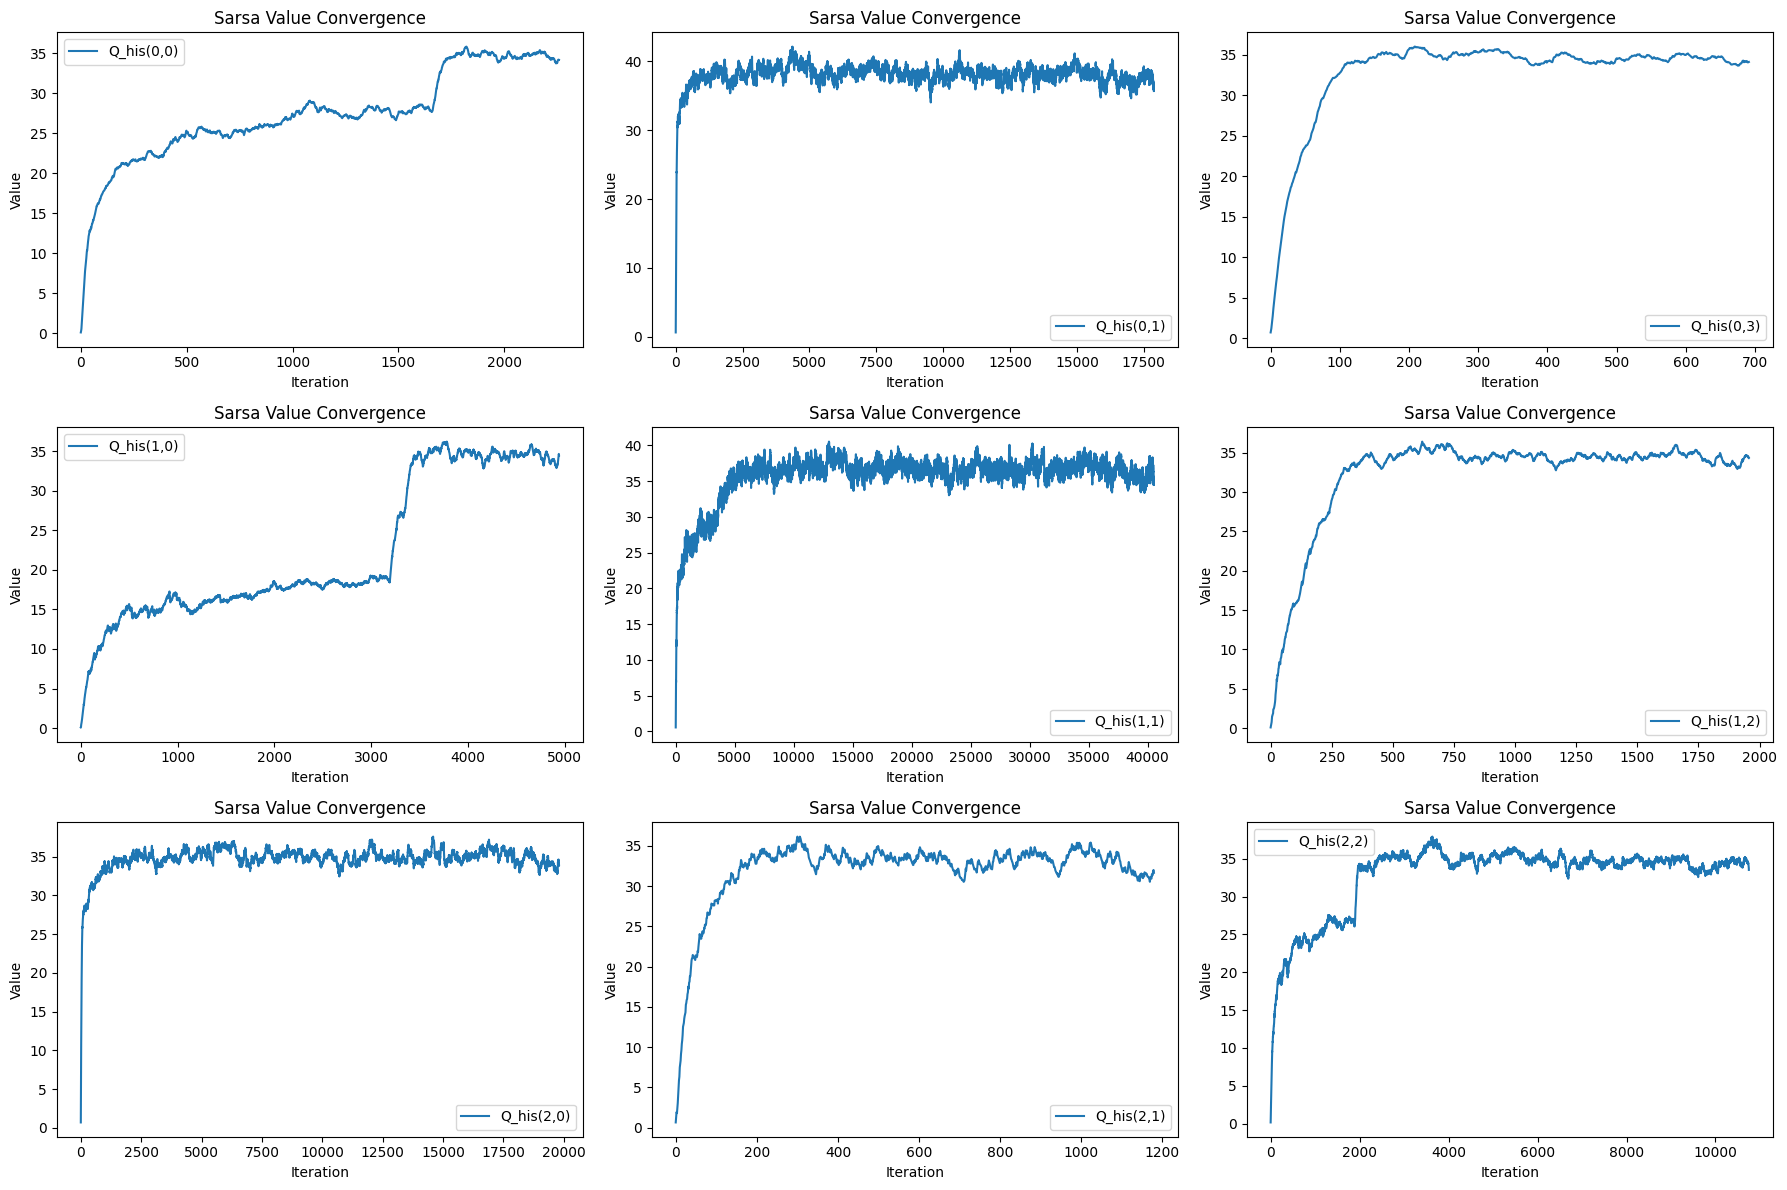

In [47]:
plt.figure(figsize=(18,12))

plt.subplot(3,3,1)
plt.plot(Q_his[0][0], label="Q_his(0,0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,2)
plt.plot(Q_his[0][1], label="Q_his(0,1)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,3)
plt.plot(Q_his[0][2], label="Q_his(0,3)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,4)
plt.plot(Q_his[1][0], label="Q_his(1,0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,5)
plt.plot(Q_his[1][1], label="Q_his(1,1)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,6)
plt.plot(Q_his[1][2], label="Q_his(1,2)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,7)
plt.plot(Q_his[2][0], label="Q_his(2,0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,8)
plt.plot(Q_his[2][1], label="Q_his(2,1)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()

plt.subplot(3,3,9)
plt.plot(Q_his[2][2], label="Q_his(2,2)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Sarsa Value Convergence")
plt.legend()


plt.tight_layout()
plt.show()

In [51]:
Q = np.zeros((3, 2), dtype = float)
Q

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [137]:
def epsilon_greedy(s, Q, epsilon):
    if np.random.rand() < epsilon:
        a = np.random.choice(len(Q[s]))
    else:
        candidate = np.flatnonzero(Q[s] == np.max(Q[s]))
        a = np.random.choice(candidate)
    return a

In [147]:
s = 1
Q = np.zeros((3, 2), dtype = float)
a = epsilon_greedy(s, Q, epsilon = 0.1)
a

np.int64(0)

In [77]:
count = {0:0,1:0}
for _ in range(1000000):
    s = 1
    Q = np.zeros((3, 2), dtype = float)
    a = epsilon_greedy(s, Q, epsilon = 0.1)
    count[a] += 1

In [79]:
print(f"a=0 p={count[0]/1000000}")
print(f"a=1 p={count[1]/1000000}")

a=0 p=0.500356
a=1 p=0.499644


In [148]:
P = {0:{0:[0.1,0.6,0.3],1:[  1,  0,  0]},
     1:{0:[0.1,0.6,0.3],1:[0.2,0.8,  0]},
     2:{0:[0.1,0.1,0.8],1:[  0,0.2,0.8]}}

R = {0:{0:[0,1,2],1:[0,-1,-2]},
     1:{0:[0,1,2],1:[0,-1,-2]},
     2:{0:[0,1,2],1:[0,-1,-2]}}

In [149]:
s = 1
a = 1
s_next = np.random.choice(len(P[s][a]), p = P[s][a])
s_next

1

In [150]:
s = 1
a = 1
s_next = 1
r_next = R[s][a][s_next]
r_next

-1

In [151]:
s = 1
a = 1
s_next = 1
r_next = -1
a_next = epsilon_greedy(s_next, Q, epsilon = 0.1)
a_next

np.int64(1)

In [152]:
sarsa_update(Q, S = 1, A = 1, R_next = -1, S_next = 1, A_next = 1, discount_factor= 0.9, learning_rate= 0.1) 
Q


array([[ 0. ,  0. ],
       [ 0. , -0.1],
       [ 0. ,  0. ]])

In [153]:
s = 1
a = 1
s_next = np.random.choice(len(P[s][a]), p = P[s][a])
s_next

0

In [156]:
s = 1
a = 1
s_next = 0
r_next = R[s][a][s_next]
r_next

0

In [157]:
s = 1
a = 1
s_next = 0
r_next = 0
a_next = epsilon_greedy(s_next, Q, epsilon = 0.1)
a_next

np.int64(0)

In [158]:
sarsa_update(Q, S = 1, A = 1, R_next = 0, S_next = 0, A_next = 0, discount_factor= 0.9, learning_rate= 0.1)
Q

array([[ 0.  ,  0.  ],
       [ 0.  , -0.09],
       [ 0.  ,  0.  ]])

In [159]:
s = 0
a = 0
s_next = np.random.choice(len(P[s][a]), p = P[s][a])
s_next

2

In [160]:
s = 0
a = 0
s_next = 2
r_next = R[s][a][s_next]
r_next

2

In [161]:
s = 0
a = 0
s_next = 2
r_next = 2
a_next = epsilon_greedy(s_next, Q, epsilon = 0.1)
a_next

np.int64(0)

In [162]:
sarsa_update(Q, S = 0, A = 0, R_next = 2, S_next = 2, A_next = 0, discount_factor= 0.9, learning_rate= 0.1) 
Q

array([[ 0.2 ,  0.  ],
       [ 0.  , -0.09],
       [ 0.  ,  0.  ]])

In [163]:
s = 2
a = 0
s_next = np.random.choice(len(P[s][a]), p = P[s][a])
s_next

2

In [164]:
s = 2
a = 0
s_next = 2
r_next = R[s][a][s_next]
r_next

2

In [165]:
s = 2
a = 0
s_next = 2
r_next = 2
a_next = epsilon_greedy(s_next, Q, epsilon = 0.1)
a_next

np.int64(0)

In [166]:
sarsa_update(Q, S = 2, A = 0, R_next = 2, S_next = 2, A_next = 0, discount_factor= 0.9, learning_rate= 0.1) 
Q

array([[ 0.2 ,  0.  ],
       [ 0.  , -0.09],
       [ 0.2 ,  0.  ]])

In [315]:
def sarsa_algorithm_test(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration):

    #initialize
    Q = np.zeros((3, 2), dtype = float)
    iteration = 0
    # the initial state is 1
    current_state = 1
    # the initial action is random explore
    current_action = Policy_fn(current_state, Q, epsilon)
    # store the history of every action value
    Q_history = {0:{0:[],1:[]},
                 1:{0:[],1:[]},
                 2:{0:[],1:[]}}

    #main loop
    while iteration < Max_iteration:
        iteration += 1
    
        #sampling next state
        S_next = np.random.choice(len(P[current_state][current_action]) , p = P[current_state][current_action])
        #sampling next action under policy
        A_next = Policy_fn(S_next, Q, epsilon)
        #sampling reward under given current action, current state and next state
        R_next = R[current_state][current_action][S_next]
        #sarsa update
        Q[current_state][current_action] = sarsa_update(Q, current_state , current_action, R_next, S_next, A_next, discount_factor, learning_rate)
        #store the action value
        Q_history[current_state][current_action].append(Q[current_state][current_action])

        current_state = S_next
        current_action = A_next

    return Q, Q_history

In [313]:
Max_iteration = 20
learning_rate = 0.1
discount_factor = 0.9
Policy_fn = epsilon_greedy
epsilon = 0.1

P = {0:{0:[0.1,0.6,0.3],1:[  1,  0,  0]},
     1:{0:[0.1,0.6,0.3],1:[0.2,0.8,  0]},
     2:{0:[0.1,0.1,0.8],1:[  0,0.2,0.8]}}

R = {0:{0:[0,1,2],1:[0,-1,-2]},
     1:{0:[0,1,2],1:[0,-1,-2]},
     2:{0:[0,1,2],1:[0,-1,-2]}}

Q, Q_history = sarsa_algorithm_test(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration)

[[0. 0.]
 [0. 0.]
 [0. 0.]]
[[ 0.   0. ]
 [ 0.  -0.1]
 [ 0.   0. ]]
[[ 0.    0.  ]
 [ 0.   -0.09]
 [ 0.    0.  ]]
[[ 0.    0.  ]
 [ 0.   -0.09]
 [ 0.    0.  ]]
[[ 0.    0.  ]
 [ 0.   -0.09]
 [ 0.    0.  ]]
[[ 0.2   0.  ]
 [ 0.   -0.09]
 [ 0.    0.  ]]
[[ 0.2   0.  ]
 [ 0.   -0.09]
 [ 0.2   0.  ]]
[[ 0.2    0.   ]
 [ 0.    -0.09 ]
 [ 0.398  0.   ]]
[[ 0.2     0.    ]
 [ 0.     -0.09  ]
 [ 0.4582  0.    ]]
[[ 0.2     0.    ]
 [ 0.1    -0.09  ]
 [ 0.4582  0.    ]]
[[ 0.2     0.    ]
 [ 0.199  -0.09  ]
 [ 0.4582  0.    ]]
[[ 0.2       0.      ]
 [ 0.420338 -0.09    ]
 [ 0.4582    0.      ]]
[[ 0.2       0.      ]
 [ 0.420338 -0.09    ]
 [ 0.653618  0.      ]]
[[ 0.2         0.        ]
 [ 0.420338   -0.09      ]
 [ 0.84708182  0.        ]]
[[ 0.2       0.      ]
 [ 0.420338 -0.09    ]
 [ 1.038611  0.      ]]
[[ 0.2         0.        ]
 [ 0.420338   -0.09      ]
 [ 1.22822489  0.        ]]
[[ 0.2         0.        ]
 [ 0.420338   -0.09      ]
 [ 1.24323282  0.        ]]
[[ 0.2         0.   

In [322]:
np.random.seed(42)
Max_iteration = 1000
learning_rate = 0.1
discount_factor = 0
Policy_fn = epsilon_greedy
epsilon = 0.1

P = {0:{0:[0.1,0.6,0.3],1:[  1,  0,  0]},
     1:{0:[0.1,0.6,0.3],1:[0.2,0.8,  0]},
     2:{0:[0.1,0.1,0.8],1:[  0,0.2,0.8]}}

R = {0:{0:[0,1,2],1:[0,-1,-2]},
     1:{0:[0,1,2],1:[0,-1,-2]},
     2:{0:[0,1,2],1:[0,-1,-2]}}

Q, Q_history = sarsa_algorithm_test(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration)
Q

array([[ 1.52665005,  0.        ],
       [ 1.28889471, -0.71634698],
       [ 1.4534705 , -1.58836946]])

In [326]:
def Q_update(Q, S, A, S_next, R_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * ( R_next + discount_factor*np.max(Q[S_next]) - Q[S][A] )
    return Q[S][A]

In [327]:
def q_algorithm_test(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration):

    #initialize
    Q = np.zeros((3, 2), dtype = float)
    iteration = 0
    # the initial state is 1
    current_state = 1
    # the initial action is random explore
    current_action = Policy_fn(current_state, Q, epsilon)
    # store the history of every action value
    Q_history = {0:{0:[],1:[]},
                 1:{0:[],1:[]},
                 2:{0:[],1:[]}}

    #main loop
    while iteration < Max_iteration:
        iteration += 1
    
        #sampling next state
        S_next = np.random.choice(len(P[current_state][current_action]) , p = P[current_state][current_action])
        #sampling next action under policy
        A_next = Policy_fn(S_next, Q, epsilon)
        #sampling reward under given current action, current state and next state
        R_next = R[current_state][current_action][S_next]
        #sarsa update
        Q[current_state][current_action] = Q_update(Q, current_state , current_action, R_next, S_next, discount_factor, learning_rate)
        #store the action value
        Q_history[current_state][current_action].append(Q[current_state][current_action])

        current_state = S_next
        current_action = A_next

    return Q, Q_history

In [331]:
np.random.seed(42)
Max_iteration = 1000
learning_rate = 0
discount_factor = 0
Policy_fn = epsilon_greedy
epsilon = 0.1

P = {0:{0:[0.1,0.6,0.3],1:[  1,  0,  0]},
     1:{0:[0.1,0.6,0.3],1:[0.2,0.8,  0]},
     2:{0:[0.1,0.1,0.8],1:[  0,0.2,0.8]}}

R = {0:{0:[0,1,2],1:[0,-1,-2]},
     1:{0:[0,1,2],1:[0,-1,-2]},
     2:{0:[0,1,2],1:[0,-1,-2]}}

Q1, Q1_history = q_algorithm_test(P, R, Policy_fn, epsilon, discount_factor, learning_rate, Max_iteration)
Q1

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [3]:
import numpy as np

In [ ]:
P = {0:{0:[0.1,0.6,0.3],1:[  1,  0,  0]},
     1:{0:[0.1,0.6,0.3],1:[0.2,0.8,  0]},
     2:{0:[0.1,0.1,0.8],1:[  0,0.2,0.8]}}

R = {0:{0:[0,1,2],1:[0,-1,-2]},
     1:{0:[0,1,2],1:[0,-1,-2]},
     2:{0:[0,1,2],1:[0,-1,-2]}}

In [6]:
p = [[0.1,0.6,0.3],
     [0.1,0.6,0.3],
     [0.1,0.1,0.8]]

I = np.eye(3,3)